Eleitoral 3

Algoritmo: HDBSCAN

Métrica:
*   min_cluster_size: 130

Best Silhouette

*   0.588266

Clusters

*   3/3

# Configuração Inicial

In [1]:
print("Instalando pm4py...")
%pip install pm4py --quiet
print("Instalação de pm4py concluída.")

Instalando pm4py...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.8 MB/s eta 0:00:00
Instalação de pm4py concluída.


In [2]:
# Instalar pacotes necessários (o script `meu_setup_utils.py` pode fazer isso,
# mas é mais robusto e explícito fazer aqui).
# Usamos --quiet para não poluir a saída.
print("Instalando pacotes (se necessário)...")
%pip install -U tqdm scikit-learn pandas matplotlib seaborn --quiet
print("Instalação de pacotes concluída.")

# Montar o Google Drive
# Nossa função `mount_google_drive` pode fazer isso, mas garantimos aqui que o caminho esteja acessível.
from google.colab import drive
import os
import sys

# Pacotes de dados e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import time

# Machine Learning e Clustering
from sklearn.cluster import DBSCAN, HDBSCAN, AgglomerativeClustering, KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.manifold import TSNE

# Process Mining (PM4Py)
from pm4py.algo.discovery.heuristics import algorithm as hm
from pm4py.visualization.heuristics_net import visualizer as hn_visualizer
from pm4py.objects.heuristics_net.obj import HeuristicsNet
from pm4py import discover_petri_net_inductive
from pm4py.algo.evaluation.replay_fitness.variants import token_replay as fitness_token_based
from pm4py.algo.evaluation.precision.variants import etconformance_token as precision_token_based
from pm4py.algo.evaluation.algorithm import apply as f1_score
from pm4py.convert import convert_to_petri_net

# Para processamento paralelo com tqdm
from tqdm.contrib.concurrent import process_map

Instalando pacotes (se necessário)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 136.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 264.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 187.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0

In [3]:
if not os.path.exists('/content/drive'):
    print("Montando Google Drive...")
    drive.mount('/content/drive')
    print("Google Drive montado.")
else:
    print("Google Drive já está montado.")

EXPERIMENT_PATH = '/content/drive/MyDrive/experimentos_mp'
UTIL_PATH = f'{EXPERIMENT_PATH}/utils'
if UTIL_PATH not in sys.path:
    sys.path.append(UTIL_PATH)
    print(f"'{UTIL_PATH}' adicionado ao sys.path.")
else:
    import data
    import importlib
    importlib.reload(data)
    print(f"'{UTIL_PATH}' já está no sys.path.")

print("\nAmbiente configurado e pronto para importar o módulo de utilidades.")

Montando Google Drive...
Mounted at /content/drive
Google Drive montado.
'/content/drive/MyDrive/experimentos_mp/utils' adicionado ao sys.path.

Ambiente configurado e pronto para importar o módulo de utilidades.


In [4]:
import experiment_functions as utils
from data import Cleaned as data

In [5]:
CASE_NAME = "case:concept:name"
ACTIVITY_NAME = "concept:name"
TIMESTAMP_NAME = "time:timestamp"

parameters = {
    "dfg_pre_cleaning_noise_thresh": 0.40
}

configs = {
    'K-means': {'n_clusters': 45},
    'DBSCAN': {'eps': 0.123375673, 'min_samples': 10},
    'AHC': {'n_clusters': 48, 'linkage': 'ward'},
    # changed for T4
    'HDBSCAN': {'min_cluster_size': 130}
}

# Code

In [6]:
court = data.eleitoral3()

In [7]:
def format_df_to_pm4py(event_log: pd.DataFrame):
        event_log = event_log.copy()[["processoID", "activity", "dataInicio", "dataFinal"]]
        event_log.rename(columns={
            'processoID': CASE_NAME,
            'activity': ACTIVITY_NAME,
            'dataInicio': 'start_timestamp',
            'dataFinal': TIMESTAMP_NAME
        }, inplace=True)
        event_log[TIMESTAMP_NAME] = pd.to_datetime(event_log[TIMESTAMP_NAME])
        return event_log.sort_values([CASE_NAME, TIMESTAMP_NAME])

df = pd.read_csv(f"{UTIL_PATH}/data/{court}.csv")
df['activity'] = df['activity'].str.capitalize()
df = format_df_to_pm4py(df).reset_index(drop=True)
df

,case:concept:name,concept:name,start_timestamp,time:timestamp
0,1861,Distribuição,2022-07-08 07:42:35.951,2022-07-08 07:42:35.951
1,1861,Conclusão,2022-07-08 07:42:35.951,2022-07-11 14:27:22.743
2,1861,Mero expediente,2022-07-11 14:27:22.743,2022-07-12 08:46:01.018
3,1861,Recebimento,2022-07-12 08:46:01.018,2022-07-12 08:46:01.473
4,1861,Documento,2022-07-12 08:46:01.473,2022-08-17 13:05:25.859
...,...,...,...,...
69351,1747,Decurso de prazo,2022-07-07 03:03:10.724,2022-07-07 03:03:11.170
69352,1747,Decurso de prazo,2022-07-07 03:03:11.170,2022-07-07 03:03:11.676
69353,1747,Trânsito em julgado,2022-07-07 03:03:11.676,2022-07-07 14:52:16.358
69354,1747,Baixa definitiva,2022-07-07 14:52:16.358,2022-07-07 14:56:09.943


In [ ]:
# Sumário do event log (análogo à Tabela 2 do Artigo 1)
# Métricas: TE (Total Events), CE (Classes of Events), Cases, Variants, VVI = Variants/Cases
_unit = 'T4U3'
_te = int(len(df))
_ce = int(df[ACTIVITY_NAME].nunique())
_cases = int(df[CASE_NAME].nunique())
_variants = int(df.groupby(CASE_NAME)[ACTIVITY_NAME].apply(tuple).nunique())
_vvi = round(_variants / _cases, 4) if _cases else float('nan')

_summary = {'unidade': _unit, 'TE': _te, 'CE': _ce, 'Cases': _cases,
            'Variants': _variants, 'VVI': _vvi}
print(_summary)

import os, csv
_out_csv = os.path.join(EXPERIMENT_PATH, 'event_log_summary.csv')
_fields = ['unidade', 'TE', 'CE', 'Cases', 'Variants', 'VVI']
_existing = []
if os.path.exists(_out_csv):
    with open(_out_csv, encoding='utf-8') as _f:
        _existing = [r for r in csv.DictReader(_f) if r['unidade'] != _unit]
with open(_out_csv, 'w', encoding='utf-8', newline='') as _f:
    _w = csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    for _r in _existing:
        _w.writerow(_r)
    _w.writerow(_summary)
print(f"Sumário gravado em: {_out_csv}")


Imagem salva com sucesso em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_cluster_spagetthi_heu_net.png


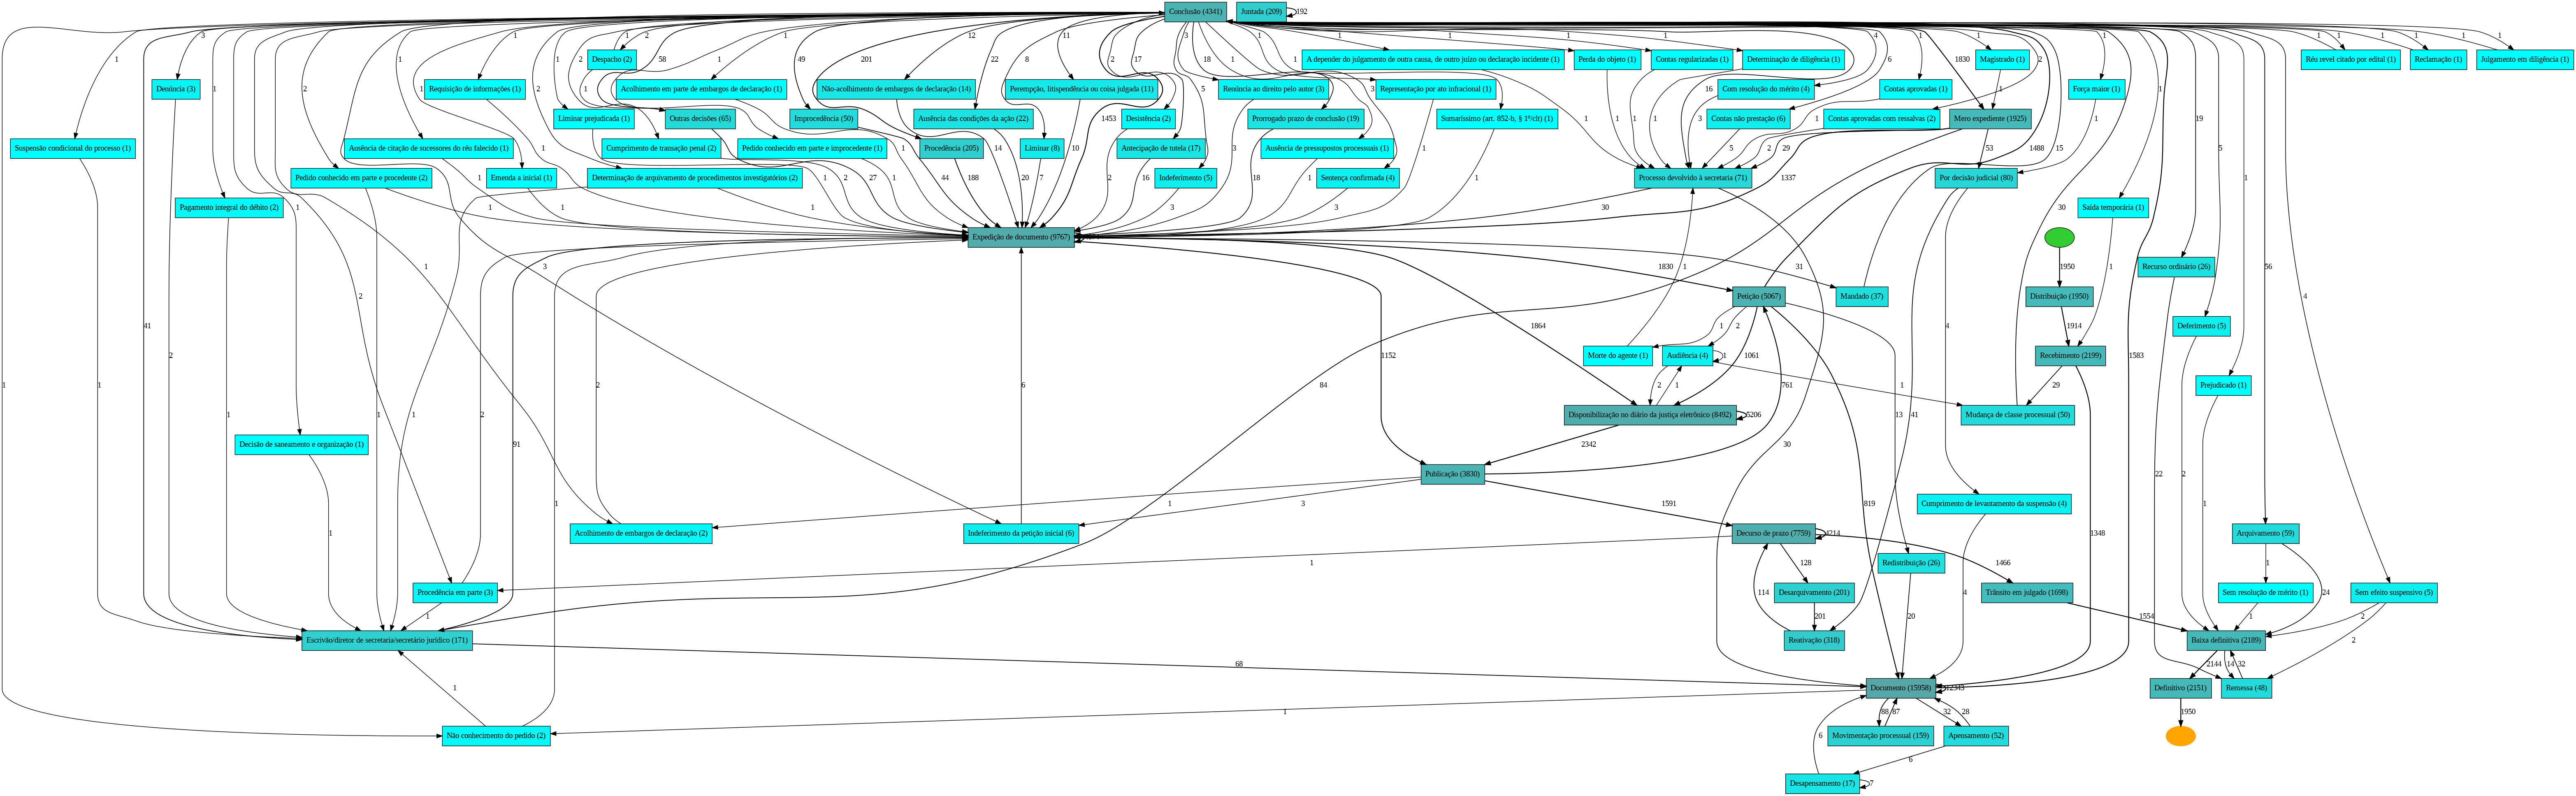

In [8]:
image_dir = f"{EXPERIMENT_PATH}/experiment_results"
os.makedirs(image_dir, exist_ok=True)

heu_net = hm.apply_heu(df,  parameters)

gviz = hn_visualizer.apply(heu_net)

image_path = os.path.join(image_dir, f"T4U3_cluster_spagetthi_heu_net.png")
hn_visualizer.save(gviz, image_path)
print(f'Imagem salva com sucesso em: {image_path}')
hn_visualizer.view(gviz)

In [9]:
activity_profile = df.groupby([CASE_NAME, ACTIVITY_NAME]).size().unstack(fill_value=0)
activity_profile_1 = activity_profile.copy()
activity_profile_1

concept:name,"A depender do julgamento de outra causa, de outro juízo ou declaração incidente",Acolhimento de embargos de declaração,Acolhimento em parte de embargos de declaração,Antecipação de tutela,Apensamento,Arquivamento,Audiência,Ausência das condições da ação,Ausência de citação de sucessores do réu falecido,Ausência de pressupostos processuais,...,Representação por ato infracional,Requisição de informações,Réu revel citado por edital,Saída temporária,Sem efeito suspensivo,Sem resolução de mérito,Sentença confirmada,"Sumaríssimo (art. 852-b, § 1º/clt)",Suspensão condicional do processo,Trânsito em julgado
case:concept:name,,,,,,,,,,,,,,,,,,,,,
1861,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
1840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1868,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1903,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1947,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1948,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [10]:
# Inicializando uma lista para armazenar os resultados
results = []

# Normalizando os dados
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(activity_profile_1)

# Inicializando colunas
activity_profile_1['cluster'] = None
activity_profile_1['silhouette'] = None

# Definindo variáveis booleanas para escolher os métodos de clusterização
use_hdbscan = True
use_dbscan = False
use_ahc = False
use_kmeans = False

cut_value = 0.05 * len(activity_profile_1)  # valor mínimo de pontos para um cluster ser considerado representativo

# Medindo o tempo de execução
start_time = time.time()

# Executando HDBSCAN
if use_hdbscan:
    print("\nHDBSCAN\n", "=" * 50)
    min_cluster_size = configs['HDBSCAN']['min_cluster_size']  # Selecionando uma configuração
    model = HDBSCAN(min_cluster_size=min_cluster_size, n_jobs=-1)
    cluster_labels = model.fit_predict(df_scaled)
    activity_profile_1['cluster'] = cluster_labels
    silhouette_vals = silhouette_samples(df_scaled, cluster_labels)
    activity_profile_1['silhouette'] = silhouette_vals

# Executando DBSCAN
if use_dbscan:
    print("\nDBSCAN\n", "=" * 50)
    eps, min_samples = configs['DBSCAN']['eps'], configs['DBSCAN']['min_samples']
    model = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = model.fit_predict(df_scaled)
    activity_profile_1['cluster'] = cluster_labels
    silhouette_vals = silhouette_samples(df_scaled, cluster_labels)
    activity_profile_1['silhouette'] = silhouette_vals

# Executando AHC
if use_ahc:
    print("\nAHC\n", "=" * 50)
    n_clusters, linkage = configs['AHC']['n_clusters'], configs['AHC']['linkage']
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    cluster_labels = model.fit_predict(df_scaled)
    activity_profile_1['cluster'] = cluster_labels
    silhouette_vals = silhouette_samples(df_scaled, cluster_labels)
    activity_profile_1['silhouette'] = silhouette_vals

# Executando K-means
if use_kmeans:
    print("\nK-means\n", "=" * 50)
    n_clusters = configs['K-means']['n_clusters']
    model = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = model.fit_predict(df_scaled)
    activity_profile_1['cluster'] = cluster_labels
    silhouette_vals = silhouette_samples(df_scaled, cluster_labels)
    activity_profile_1['silhouette'] = silhouette_vals

# Exibindo resultados
print(activity_profile_1[['cluster', 'silhouette']])


HDBSCAN
concept:name       cluster  silhouette
case:concept:name                     
1861                1    0.371562
12               -1   -0.045624
1840                0    0.589678
1868               -1   -0.190903
1903               -1   -0.265284
...                    ...         ...
1946               -1   -0.128779
1947               -1   -0.327496
1948               -1   -0.298489
1949               -1   -0.191685
1747               -1   -0.287207

[1950 rows x 2 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [11]:
# Suponha que 'activity_profile_1' é o seu DataFrame que inclui os dados de clustering

# Calculando a média dos scores de silhouette para clusters combinados
combined_silhouette_avg = activity_profile_1.groupby('cluster')['silhouette'].mean().sort_values(ascending=False)

# Calculando a contagem de casos para clusters combinados
combined_count = activity_profile_1['cluster'].value_counts().sort_values(ascending=False)

# Criando uma DataFrame com as métricas dos clusters com mais volumes de dados
# Para este exemplo, vamos considerar os top 5 clusters com mais dados
top_clusters = combined_count.head(20).index
metrics_table = pd.DataFrame({
    'Cluster Label': top_clusters,
    'Count': combined_count[top_clusters].values,
    'Average Silhouette Score': combined_silhouette_avg[top_clusters].values
})

# Ordenando a tabela pela contagem de pontos (volumes de dados)
metrics_table.sort_values(by='Count', ascending=False, inplace=True)

# Exibindo a tabela
print(metrics_table)

   Cluster Label  Count  Average Silhouette Score
0              1   1326                  0.512304
1             -1    333                 -0.311382
2              2    154                  0.641403
3              0    137                  0.616848


/tmp/ipykernel_5055/2919261574.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='silhouette', data=activity_profile_1, order=cluster_order_raw, ax=ax, palette='Set3')


Imagem salva com sucesso no Drive em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_silhouette_by_cluster.png


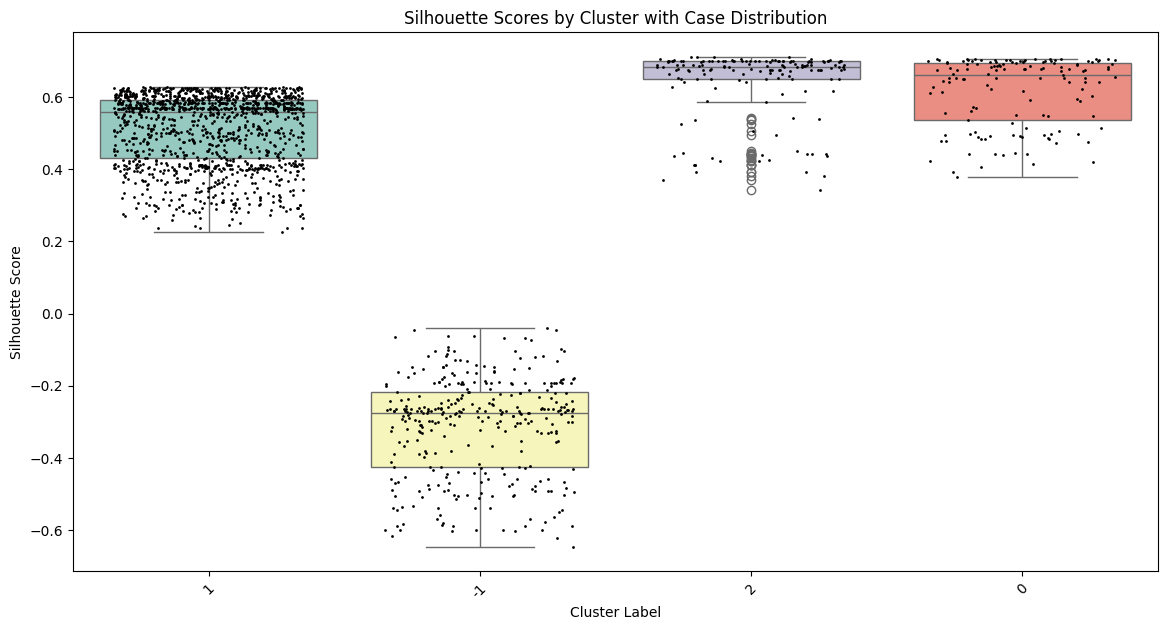

In [12]:
cluster_counts_raw = activity_profile_1['cluster'].value_counts()
cluster_order_raw = cluster_counts_raw.index.tolist()


fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(x='cluster', y='silhouette', data=activity_profile_1, order=cluster_order_raw, ax=ax, palette='Set3')
sns.stripplot(x='cluster', y='silhouette', data=activity_profile_1, order=cluster_order_raw, ax=ax, color='black', size=2, jitter=0.35)

ax.set_xlabel('Cluster Label')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Scores by Cluster with Case Distribution')
plt.xticks(rotation=45)

image_dir = f"{EXPERIMENT_PATH}/experiment_results"
os.makedirs(image_dir, exist_ok=True)
image_path = f"{image_dir}/T4U3_silhouette_by_cluster.png"
plt.savefig(image_path, bbox_inches='tight', dpi=300)
print(f'Imagem salva com sucesso no Drive em: {image_path}')

plt.show()

In [13]:
cluster_counts_raw

cluster
 1    1326
-1     333
 2     154
 0     137
Name: count, dtype: int64

/tmp/ipykernel_5055/1143345505.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='silhouette', data=activity_profile_no_outliers, order=cluster_order, ax=ax, palette='Set3')


Imagem salva com sucesso no Drive em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_silhouette_by_cluster_no_outliers.png


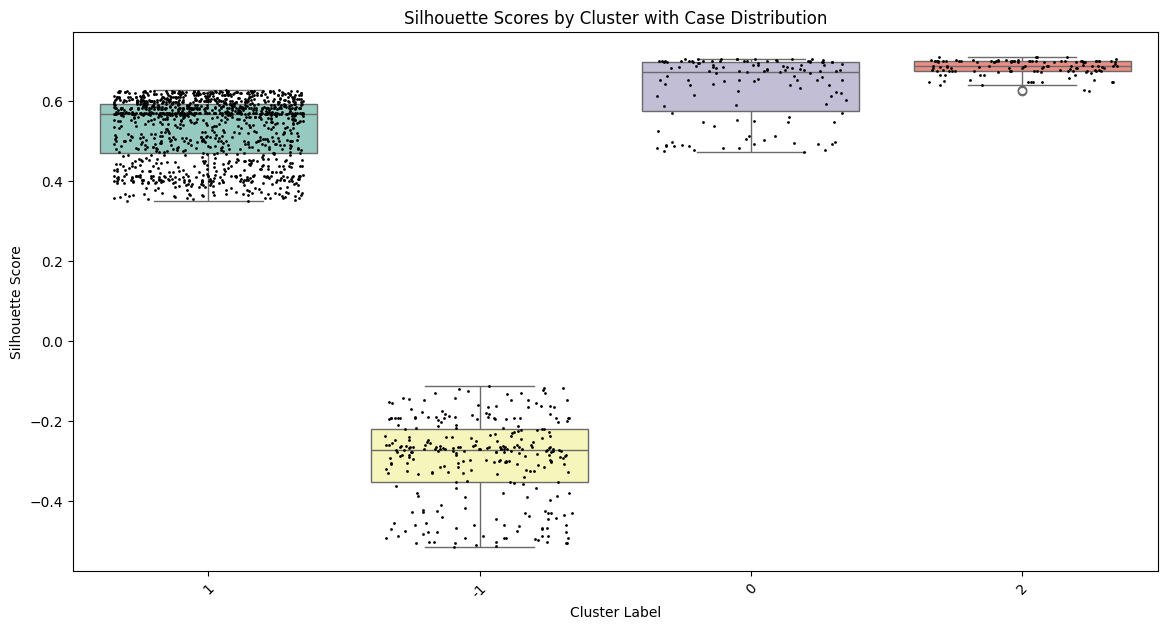

In [14]:
# Função para remover outliers com base no IQR
def remove_outliers(df, col_group, col_value):
    filtered_df = pd.DataFrame(columns=df.columns)  # DataFrame vazio para armazenar dados sem outliers

    # Itera sobre cada grupo (cluster)
    for name, group in df.groupby(col_group):
        Q1 = group[col_value].quantile(0.25)
        Q3 = group[col_value].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 0.5 * IQR
        upper_bound = Q3 + 0.5 * IQR

        # Filtra valores dentro dos limites
        filtered_group = group[(group[col_value] >= lower_bound) & (group[col_value] <= upper_bound)]
        filtered_df = pd.concat([filtered_df, filtered_group])

    return filtered_df

# Remover outliers do DataFrame original
activity_profile_no_outliers = remove_outliers(activity_profile_1, 'cluster', 'silhouette')

# Redefinir a contagem e ordem dos clusters após a remoção dos outliers
cluster_counts = activity_profile_no_outliers['cluster'].value_counts()
cluster_order = cluster_counts.index.tolist()

# Criar o gráfico sem outliers
fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(x='cluster', y='silhouette', data=activity_profile_no_outliers, order=cluster_order, ax=ax, palette='Set3')
sns.stripplot(x='cluster', y='silhouette', data=activity_profile_no_outliers, order=cluster_order, ax=ax, color='black', size=2, jitter=0.35)

ax.set_xlabel('Cluster Label')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Scores by Cluster with Case Distribution')
plt.xticks(rotation=45)

image_dir = f"{EXPERIMENT_PATH}/experiment_results"
os.makedirs(image_dir, exist_ok=True)
image_path = f"{image_dir}/T4U3_silhouette_by_cluster_no_outliers.png"
plt.savefig(image_path, bbox_inches='tight', dpi=300)
print(f'Imagem salva com sucesso no Drive em: {image_path}')

plt.show()

In [15]:
df_scaled_no_outliers = activity_profile_no_outliers.drop(["cluster","silhouette"], axis=1)

# Normalizando os dados
scaler = MinMaxScaler()
df_scaled_no_outliers = scaler.fit_transform(df_scaled_no_outliers)
df_scaled_no_outliers

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.33333333],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.33333333],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.33333333],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.33333333],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.33333333],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.33333333]])

In [16]:
silhouette_vals = silhouette_samples(df_scaled_no_outliers,
                                     activity_profile_no_outliers['cluster'])

activity_profile_no_outliers["silhouette"] = silhouette_vals
combined_silhouette_avg = activity_profile_no_outliers.groupby('cluster')['silhouette'].mean().sort_values(ascending=False)
combined_count = activity_profile_no_outliers['cluster'].value_counts().sort_values(ascending=False)

total_casos = df['case:concept:name'].nunique()

# Calcular o limite de 5% do total de casos
limite_5 = total_casos * 0.05



top_clusters = combined_count.head(40).index
metrics_table = pd.DataFrame({
    'Cluster Label': top_clusters,
    'Count': combined_count[top_clusters].values,
    'Raw Count': cluster_counts_raw[top_clusters].values,
    'Average Silhouette Score': combined_silhouette_avg[top_clusters].values
})
metrics_table.sort_values(by=["Count"],
                          ascending=False, inplace=True)

# Filtrar os clusters com contagem maior que 5% do total de casos

top_clusters = metrics_table[metrics_table['Raw Count'] > limite_5]
#top_clusters = top_clusters[top_clusters["Cluster Label"] != -1]

top_labels = top_clusters['Cluster Label']

top_clusters

,Cluster Label,Count,Raw Count,Average Silhouette Score
0,1,1212,1326,0.331732
1,-1,286,333,-0.267972
2,0,126,137,0.527248
3,2,123,154,0.648329


In [17]:
image_dir = f"{EXPERIMENT_PATH}/experiment_results"
os.makedirs(image_dir, exist_ok=True)
image_path = f"{image_dir}/T4U3_tsne.png"

def tsne(profile, n_clusters):

  # Limitar n_clusters a no máximo 10
  n_clusters = min(n_clusters, 10)

  # Definir uma paleta de cores
  colors = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple', 'brown']

  # Normalizando os dados
  scaler = MinMaxScaler()
  df_scaled_tsne = scaler.fit_transform(profile.drop(['cluster', 'silhouette'], axis=1))

  # Identificar os principais clusters
  cluster_counts = profile['cluster'].value_counts()
  top_clusters = cluster_counts.nlargest(n_clusters).index.tolist()
  color_map = dict(zip(top_clusters, colors[:n_clusters]))
  default_color = 'gray'  # Cor para os demais clusters

  # Mapear cores aos clusters
  mapped_colors = [color_map.get(label, default_color) for label in profile['cluster']]

  # Executando t-SNE
  tsne = TSNE(n_components=2, perplexity=30, learning_rate=200)
  tsne_results = tsne.fit_transform(df_scaled_tsne)

  # Plotando os Resultados do t-SNE
  plt.figure(figsize=(12,8))
  scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=mapped_colors, alpha=0.7)

  # Criando uma legenda para os clusters destacados
  for label, color in color_map.items():
      plt.scatter([], [], color=color, label=f'Cluster {label}')
  plt.scatter([], [], color=default_color, label='Other Clusters')

  plt.legend()
  plt.title('t-SNE projection of the data')
  plt.xlabel('Component 1')
  plt.ylabel('Component 2')
  plt.savefig(image_path, bbox_inches='tight', dpi=300)
  print(f'Imagem salva com sucesso no Drive em: {image_path}')
  plt.show()

Imagem salva com sucesso no Drive em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_tsne.png


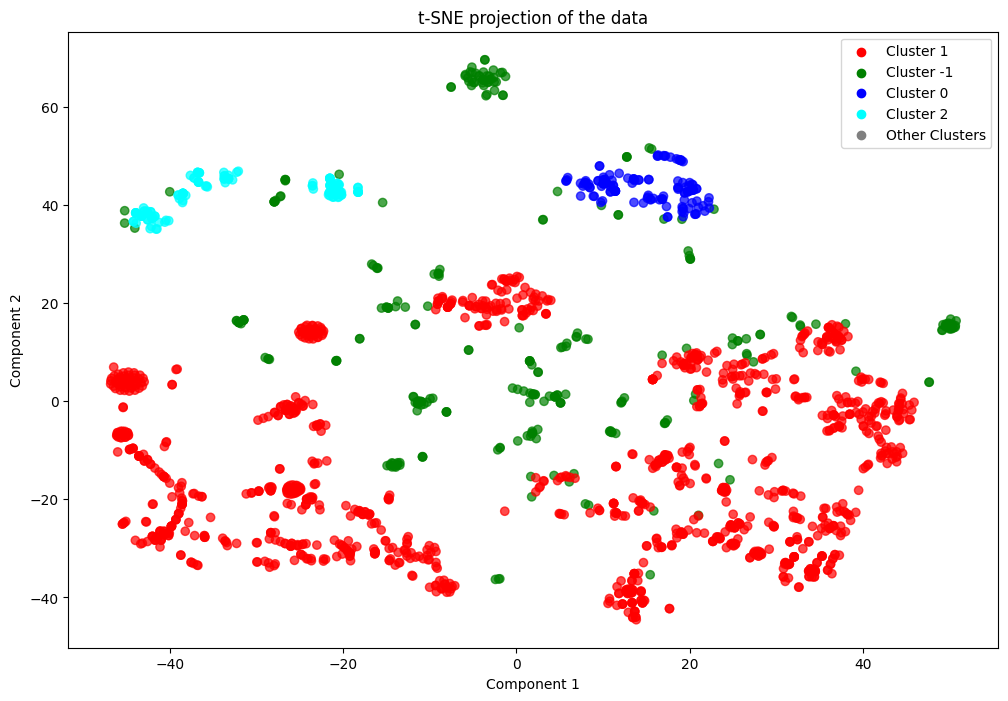

In [18]:
tsne(activity_profile_no_outliers, len(top_labels))

In [19]:
def get_case_avg_fitness(args: tuple[pd.DataFrame, str, list]):
    event_log, case_id, model_items = args
    trace = event_log[event_log[CASE_NAME] == case_id]
    # metrics = f1_score(trace, *model_items)
    # return case_id, metrics["fscore"]

    precision = precision_token_based.apply(trace, *model_items)
    return case_id, precision

def get_cluster_fitness_metrics(event_log: pd.DataFrame, pn_items):
    lowest_fitness = 0
    highest_fitness = 0
    highest_fitness_case = None
    case_list = event_log[CASE_NAME].unique()
    case_amount = event_log[CASE_NAME].nunique()

    args_list = [(event_log, case_id, pn_items) for case_id in case_list]
    fitness_values = process_map(get_case_avg_fitness, args_list, leave=True,
                                 chunksize=10, total=case_amount, position=0)

    for case_id, fitness in fitness_values:
        if fitness > highest_fitness:
            highest_fitness = fitness
            highest_fitness_case = case_id
        if lowest_fitness == 0 or fitness < lowest_fitness:
            lowest_fitness = fitness

    return highest_fitness_case, lowest_fitness

def get_cluster_events(dataframe: pd.DataFrame, activity_profile: pd.DataFrame,
                       cluster: int) -> pd.DataFrame:
    mask = activity_profile["cluster"] == cluster
    npus = activity_profile[mask].index
    return dataframe[dataframe[CASE_NAME].isin(npus)]

In [20]:
activity_profile_no_outliers = activity_profile_no_outliers[activity_profile_no_outliers['cluster'].isin(top_labels)]
cluster_names = sorted(activity_profile_no_outliers["cluster"].unique())
cluster_names

[-1, 0, 1, 2]

In [21]:
def calculate_cfc(heu_net: HeuristicsNet):
    cfc = 0
    # Preparando um dicionário para contar saídas de cada atividade
    activity_outputs = {}
    for (source, target), count in heu_net.dfg.items():
        if source in activity_outputs:
            activity_outputs[source].add(target)
        else:
            activity_outputs[source] = {target}

    # Calculando CFC baseado em múltiplas saídas
    for source, targets in activity_outputs.items():
        if len(targets) > 1:
            cfc += len(targets)  # Soma o número de saídas únicas como contribuição ao CFC

    return cfc

def calculate_cnc(heu_net):
    # Contar o número de nós (atividades)
    number_of_nodes = len(heu_net.activities)

    # Contar o número de conexões únicas (arcos)
    number_of_arcs = len(heu_net.dfg)

    # Calcular o CNC
    if number_of_nodes > 0:
        cnc = number_of_arcs / number_of_nodes
    else:
        cnc = 0  # Evitar divisão por zero

    return cnc

# Lista de logs de eventos
filtered_df = []
for cluster in cluster_names:
    filtered_df.append(get_cluster_events(df, activity_profile_no_outliers, cluster))

event_logs = filtered_df
court_names = []
court_names.append('R')
for i in cluster_names:
  court_names.append(i)


parameters = {
    "dfg_pre_cleaning_noise_thresh": 0.40
}

#heu_net = hm.apply_heu(event_log_hm,  parameters)
#heu_net = hm.apply_heu(filtered_eventlog,  parameters)

heu_net = hm.apply_heu(df,  parameters)

# Calcular o número de nós (atividades)
number_of_nodes = len(heu_net.activities)

# Calcular o número de arcos (conexões entre as atividades)
number_of_arcs = len(heu_net.dfg)

# Calcular a densidade, se possível
if number_of_nodes > 1:
    max_possible_arcs = number_of_nodes * (number_of_nodes - 1)  # direcionado sem laços
    density = number_of_arcs / max_possible_arcs
else:
    density = 0

# Lista para armazenar os resultados
results = []

# Calculando o CFC
cfc_value = calculate_cfc(heu_net)

# Calculando o CNC
cnc_value = calculate_cnc(heu_net)

results.append({
        "Clusters": court_names[0],
        "Number of Nodes": number_of_nodes,
        "Number of Arcs": number_of_arcs,
        #"Density": density,
        "CFC": cfc_value,
        #"CNC": cnc_value
    })


# Processar cada log de eventos
for i, event_log in enumerate(event_logs):
    # Aplicar o algoritmo Heuristics Miner
    heu_net = hm.apply_heu(event_log, parameters=parameters)  # Desempacotar a tupla corretamente

    # Calcular o número de nós (atividades)
    number_of_nodes = len(heu_net.activities)  # Assumindo que 'heu_net' é o objeto correto agora

    # Contar a quantidade de conexões únicas no DFG
    number_of_arcs = len(heu_net.dfg)

    # Calcular a densidade, se possível
    if number_of_nodes > 1:
        max_possible_arcs = number_of_nodes * (number_of_nodes - 1)  # direcionado sem laços
        density = number_of_arcs / max_possible_arcs
    else:
        density = 0

    cfc_value = calculate_cfc(heu_net)
    cnc_value = calculate_cnc(heu_net)

    # Adicionar os resultados à lista
    results.append({
        "Clusters": court_names[i+1],
        "Number of Nodes": number_of_nodes,
        "Number of Arcs": number_of_arcs,
        #"Density": density,
        "CFC": cfc_value,
        #"CNC": cnc_value
    })



# Converter a lista de resultados em um DataFrame do Pandas para visualização tabular
results_df = pd.DataFrame(results)

# Adicionando a coluna 'complexity' que é a soma de 'Number of Nodes', 'Number of Arcs' e 'CFC'
results_df['complexity'] = results_df['Number of Nodes'] + results_df['Number of Arcs'] + results_df['CFC']

# Normalizando a coluna 'complexity' com MinMaxScaler
scaler = MinMaxScaler()
results_df['complexity_normalized'] = scaler.fit_transform(results_df[['complexity']])

# Invertendo a normalização (1 - valor atual) e renomeando como 'simplicity'
results_df['simplicity'] = 1 - results_df['complexity_normalized']

# Ajustando a coluna 'simplicity' para exibir valores com até 8 casas decimais
results_df['simplicity'] = results_df['simplicity'].round(8)

simplicity_top_clusters = results_df[0:6]

simplicity_top_clusters

,Clusters,Number of Nodes,Number of Arcs,CFC,complexity,complexity_normalized,simplicity
0,R,83,180,122,385,1.000000,0.000000
1,-1,77,163,111,351,0.896024,0.103976
2,0,19,33,22,74,0.048930,0.951070
3,1,21,48,42,111,0.162080,0.837920
4,2,15,25,18,58,0.000000,1.000000


############# Cluster 1 ###############
Imagem salva com sucesso em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_cluster_1_heu_net.png


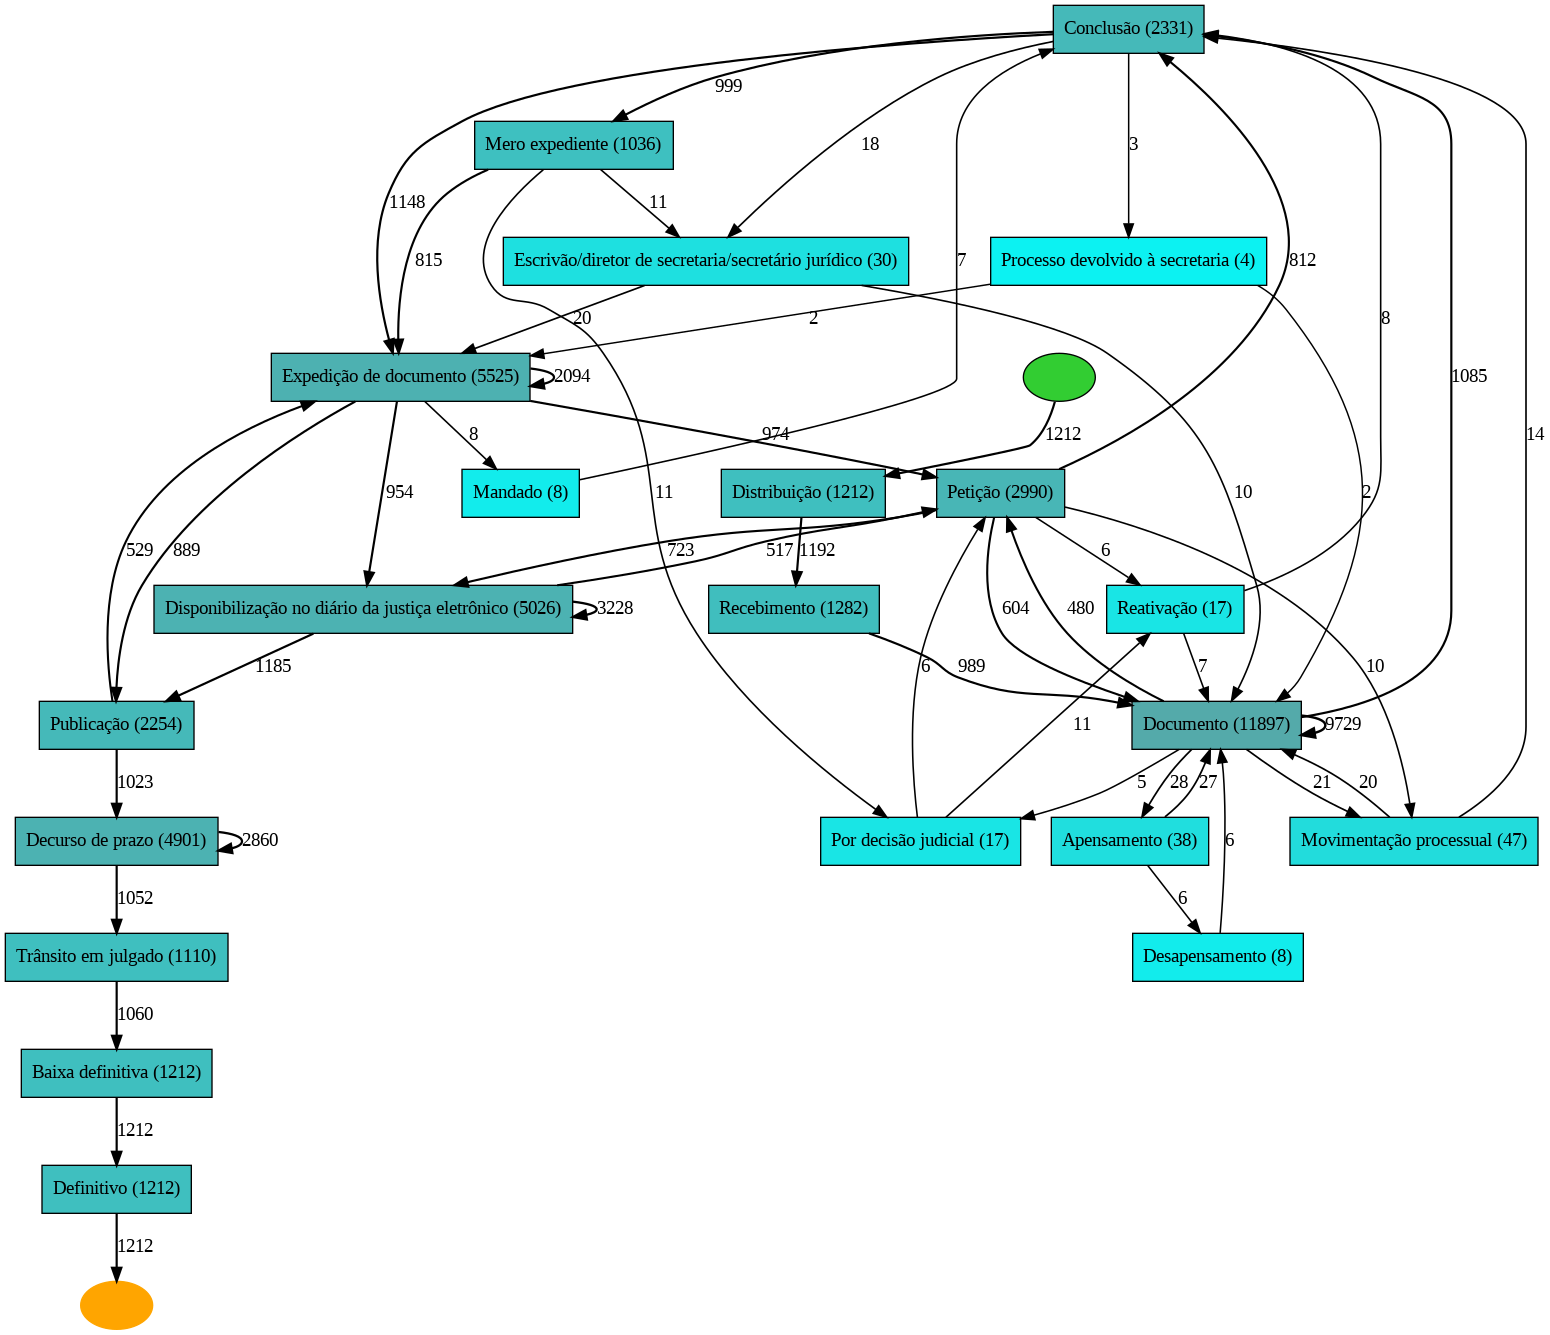

############# Cluster -1 ###############
Imagem salva com sucesso em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_cluster_-1_heu_net.png


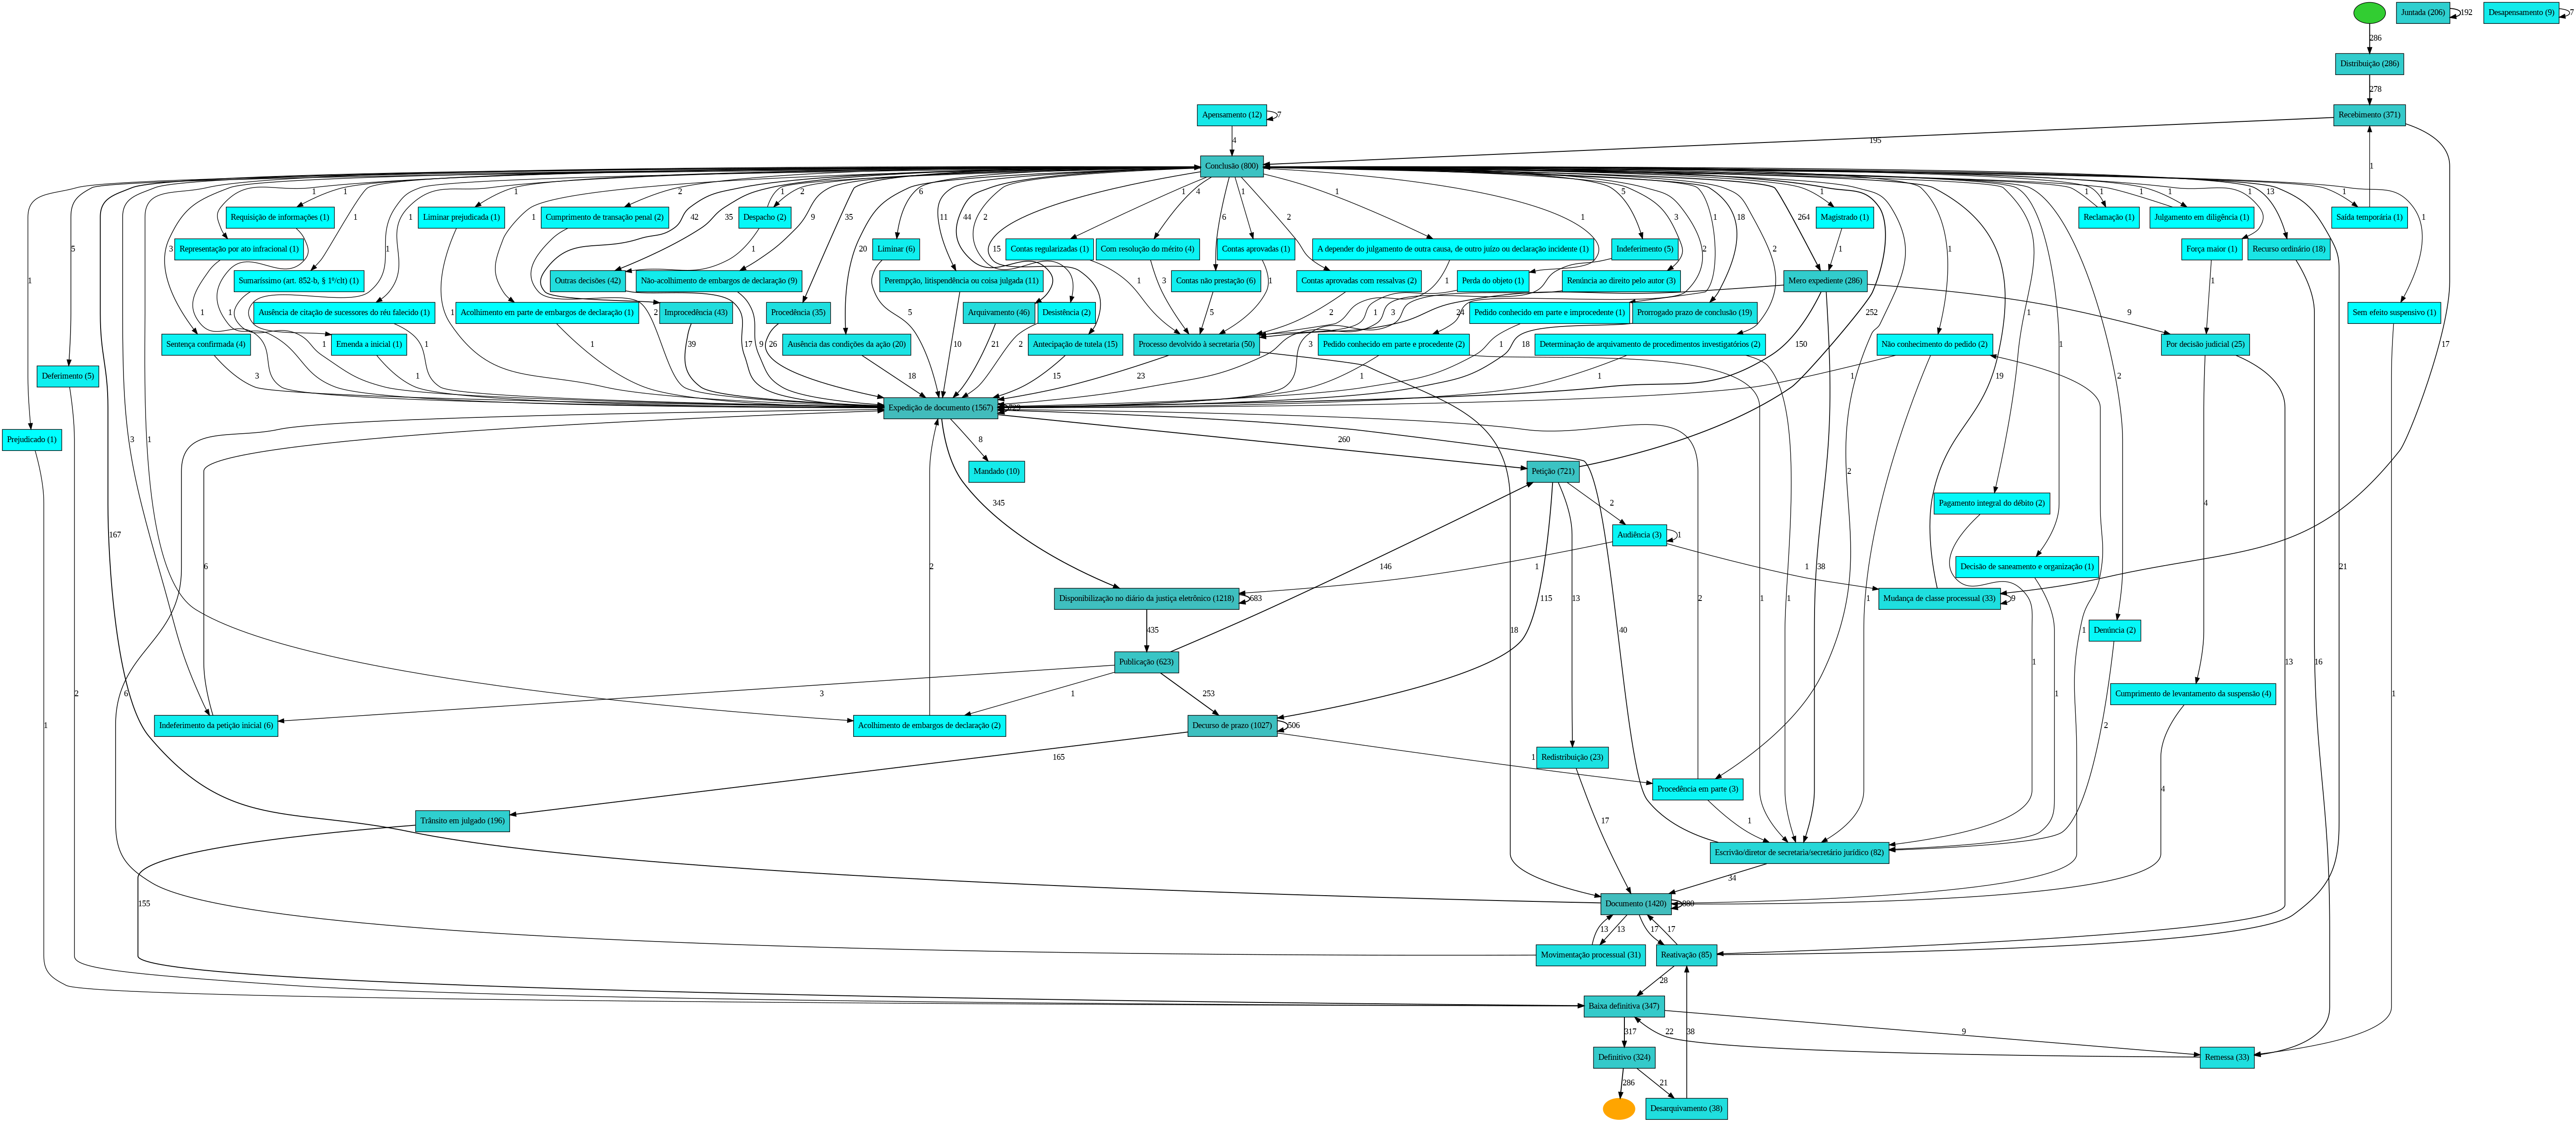

############# Cluster 0 ###############
Imagem salva com sucesso em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_cluster_0_heu_net.png


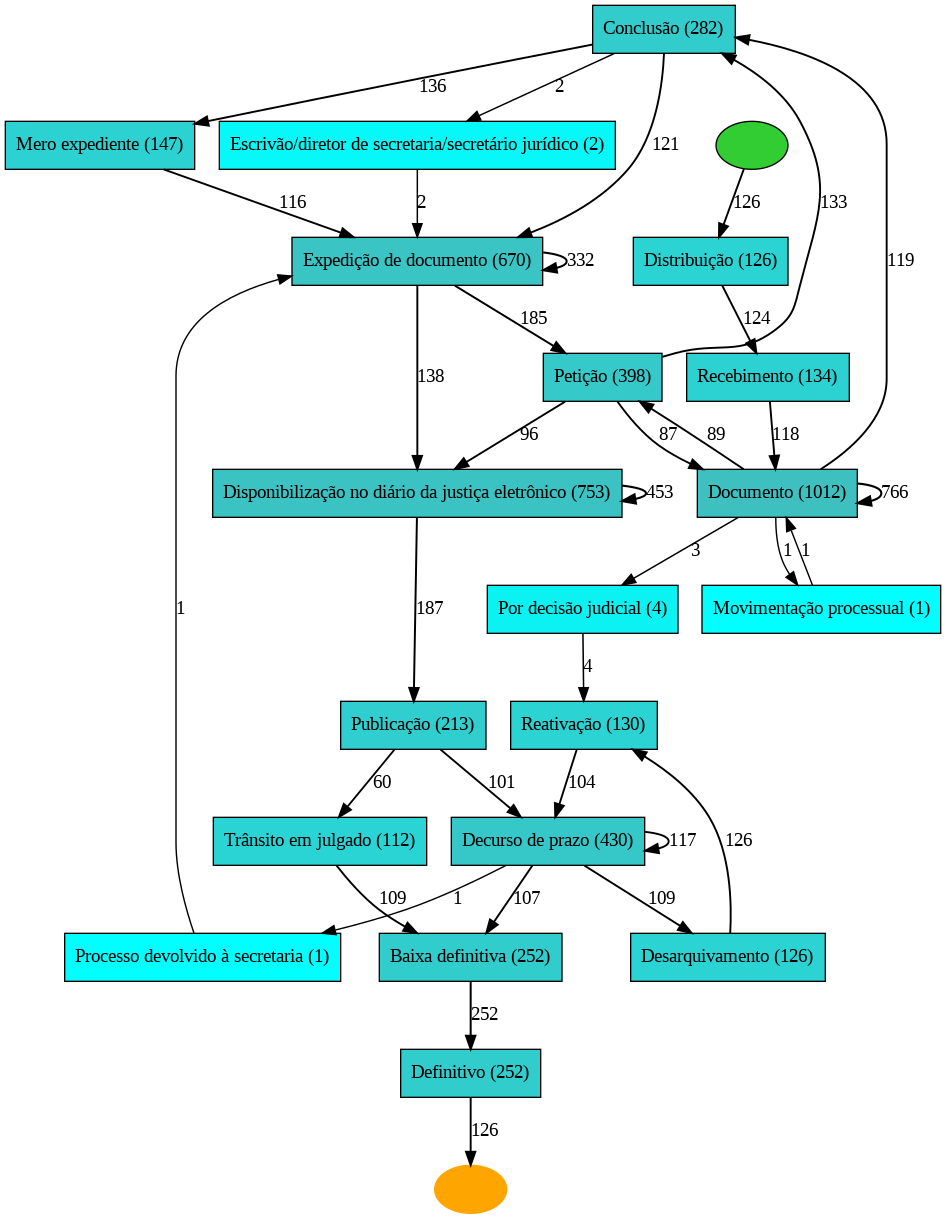

############# Cluster 2 ###############
Imagem salva com sucesso em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_cluster_2_heu_net.png


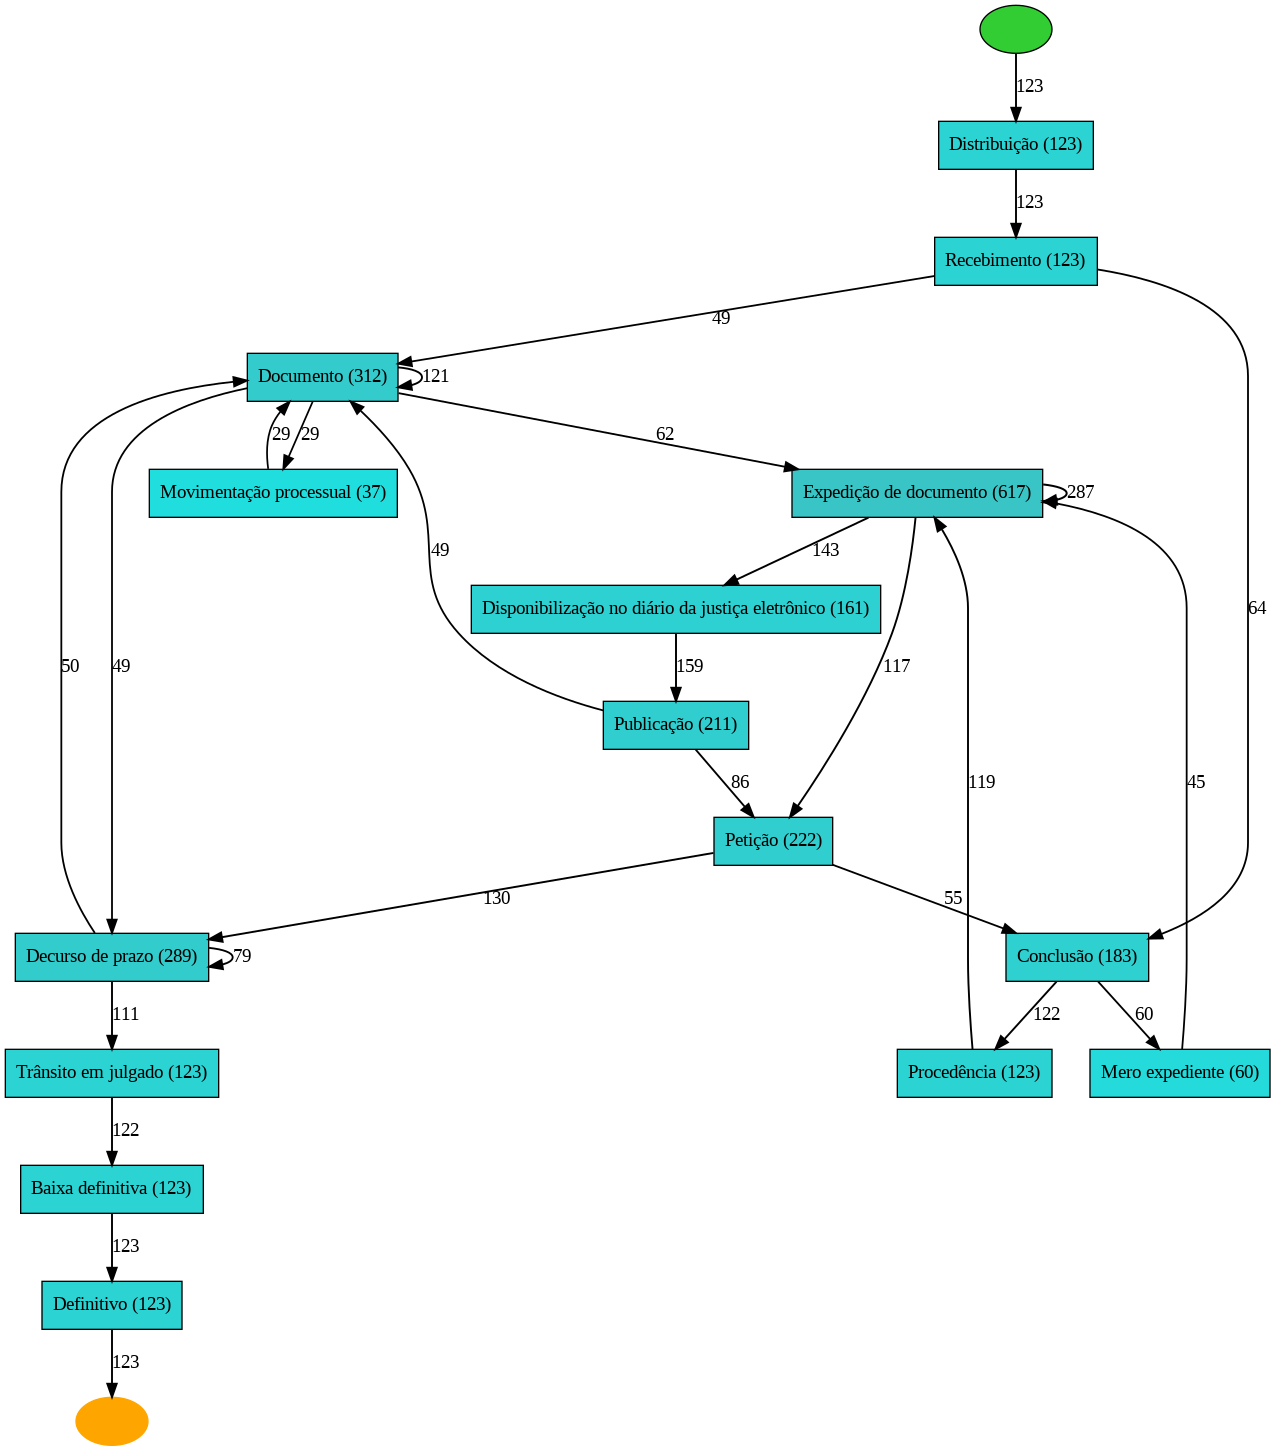

In [22]:
image_dir = f"{EXPERIMENT_PATH}/experiment_results"
os.makedirs(image_dir, exist_ok=True)

for cluster in top_clusters["Cluster Label"]:
  c0 = get_cluster_events(df, activity_profile_no_outliers, cluster)
  heu_net = hm.apply_heu(c0,  parameters)

  gviz = hn_visualizer.apply(heu_net)
  print(f"############# Cluster {cluster} ###############")

  image_path = os.path.join(image_dir, f"T4U3_cluster_{cluster}_heu_net.png")
  hn_visualizer.save(gviz, image_path)
  print(f'Imagem salva com sucesso em: {image_path}')

  hn_visualizer.view(gviz)


In [23]:
clusters_threshold: list[float] = []
best_cluster_cases: list[tuple] = []
cluster_models: list[tuple] = []

#activity_profile_no_outliers['']

activity_profile_no_outliers = activity_profile_no_outliers[activity_profile_no_outliers['cluster'].isin(top_labels)]

cluster_names = sorted(activity_profile_no_outliers["cluster"].unique())
for c_name in cluster_names:
    cluster_events = get_cluster_events(df, activity_profile_no_outliers, c_name)
    heu_net = hm.apply_heu(cluster_events,  parameters)
    pn_items = convert_to_petri_net(heu_net)
    # pn_items = discover_petri_net_inductive(cluster_events, True)
    cluster_models.append((c_name, pn_items, cluster_events))

for c_name, pn_items, events in cluster_models:
    best_case, c_threshold = get_cluster_fitness_metrics(events, pn_items)
    clusters_threshold.append(c_threshold)
    best_cluster_cases.append((best_case, pn_items))
    print(f"\nCluster {c_name}: {best_case} with distance of {c_threshold}")

pd.DataFrame([clusters_threshold])

  0%|          | 0/286 [00:00<?, ?it/s]


Cluster -1: 1868 with distance of 0.039215686274509776


  0%|          | 0/126 [00:00<?, ?it/s]


Cluster 0: 994 with distance of 0.2650602409638554


  0%|          | 0/1212 [00:00<?, ?it/s]


Cluster 1: 1886 with distance of 0.1590106007067138


  0%|          | 0/123 [00:00<?, ?it/s]


Cluster 2: 141 with distance of 0.32499999999999996


,0,1,2,3
0,0.039216,0.26506,0.159011,0.325


In [24]:
matrix_values: list[list[float]] = [[] for x in range(len(best_cluster_cases))]
matrix_threshold: list[list[float]] = [[] for x in range(len(best_cluster_cases))]

for index_1, (case_id_1, _) in enumerate(best_cluster_cases):
  threshold = clusters_threshold[index_1]
  for index_2, (case_id_2, petri_net) in enumerate(best_cluster_cases):
    if case_id_1 is None or case_id_2 is None:
      matrix_values[index_1].append(0)
      matrix_threshold[index_1].append(True)
    else:
      _, score = get_case_avg_fitness((df, case_id_1, petri_net))

      matrix_values[index_1].append(score)
      matrix_threshold[index_1].append(threshold > score)
  matrix_values[index_1].append(threshold)

replaying log with TBR, completed traces ::   0%|          | 0/38 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/38 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/38 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/38 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/41 [00:00<?, ?it/s]

...

replaying log with TBR, completed traces ::   0%|          | 0/32 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/16 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/16 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/16 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/16 [00:00<?, ?it/s]

In [25]:
fitness_list = list()

heu_net = hm.apply_heu(df,  parameters)
pn_items = convert_to_petri_net(heu_net)

case_ids = activity_profile_1.index
fitness_score = fitness_token_based.apply(df, *pn_items)["average_trace_fitness"]
precision_score = precision_token_based.apply(df, *pn_items)
f1 = f1_score(df, *pn_items)["fscore"]

act_volume = df.groupby(CASE_NAME).size().mean()
fitness_list.append(('R', act_volume, fitness_score, precision_score, f1))


for cluster_id in cluster_names:
  c_events = get_cluster_events(df, activity_profile_no_outliers, cluster_id)

  heu_net = hm.apply_heu(c_events,  parameters)
  pn_items = convert_to_petri_net(heu_net)

  case_ids = activity_profile_no_outliers[activity_profile_no_outliers["cluster"] == cluster_id].index
  fitness_score = fitness_token_based.apply(c_events, *pn_items)["average_trace_fitness"]
  precision_score = precision_token_based.apply(c_events, *pn_items)
  f1 = f1_score(c_events, *pn_items)["fscore"]

  act_volume = c_events.groupby(CASE_NAME).size().mean()
  fitness_list.append((str(cluster_id), act_volume, fitness_score, precision_score, f1))

fitness_df = pd.DataFrame(fitness_list, columns=["cluster", "mean_volume", "fitness", "precision", "f1"])

fitness_df = fitness_df.sort_values(by="cluster", ascending=True)
top_clusters.sort_values(by="Cluster Label", ascending=True, inplace=True)

# Redefinir os índices de ambos os DataFrames para garantir que estejam alinhados
fitness_df = fitness_df.reset_index(drop=True)
top_clusters = top_clusters.reset_index(drop=True)
simplicity_top_clusters = simplicity_top_clusters.reset_index(drop=True)

fitness_df['simplicity'] = simplicity_top_clusters['simplicity']
fitness_df['silhouette'] = top_clusters['Average Silhouette Score']
fitness_df


replaying log with TBR, completed traces ::   0%|          | 0/1520 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/33400 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/1520 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/33400 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/263 [00:00<?, ?it/s]

...

replaying log with TBR, completed traces ::   0%|          | 0/67 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/762 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/67 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/762 [00:00<?, ?it/s]

,cluster,mean_volume,fitness,precision,f1,simplicity,silhouette
0,-1,35.559441,0.917687,0.335387,0.491953,0.000000,-0.267972
1,0,40.039683,0.931455,0.497152,0.648646,0.103976,0.527248
2,1,34.783003,0.967779,0.511204,0.669197,0.951070,0.331732
3,2,23.008130,0.942254,0.587445,0.724560,0.837920,0.648329
4,R,35.567179,0.911776,0.486111,0.635723,1.000000,NaN


In [26]:
n_top_atividades = 40

# Remover a coluna 'silhouette' do DataFrame
df_description = activity_profile_1.drop(["silhouette"], axis=1)

# Garantir que todos os dados possam ser comparados como números
df_description = df_description.apply(pd.to_numeric, errors='coerce')

# Extrair a coluna de cluster
clusters = df_description['cluster']

df_description.drop(['cluster'], axis=1, inplace=True)

# Calcular a soma de cada atividade no dataset completo
total_ativ_por_atividade = df_description.sum()

# Selecionar as N atividades mais frequentes
top_atividades = total_ativ_por_atividade.nlargest(n_top_atividades).index

# Filtrar o DataFrame para incluir apenas as atividades mais frequentes
df_filtrado = df_description[top_atividades]

# Calcular o número total de processos
total_processos = len(df_description)

# Calcular a proporção global de cada uma das N atividades mais frequentes
prop_ativ_total = total_ativ_por_atividade[top_atividades] / total_processos

# Calcular a soma de atividades por cluster
total_ativ_por_cluster = df_filtrado.join(clusters).groupby('cluster').sum()

# Calcular o número de processos por cluster
n_processos_por_cluster = clusters.value_counts()

# Calcular a proporção de atividades por cluster, normalizado pelo número de processos
prop_ativ_por_cluster = total_ativ_por_cluster.div(n_processos_por_cluster, axis=0)

# Calcular o Lift por cluster, normalizado
lift_por_cluster = prop_ativ_por_cluster.div(prop_ativ_total, axis=1)

# Substituir NaN por 0
lift_por_cluster = lift_por_cluster.fillna(0)

Imagem salva com sucesso no Drive em: /content/drive/MyDrive/experimentos_mp/experiment_results/T4U3_activities.png


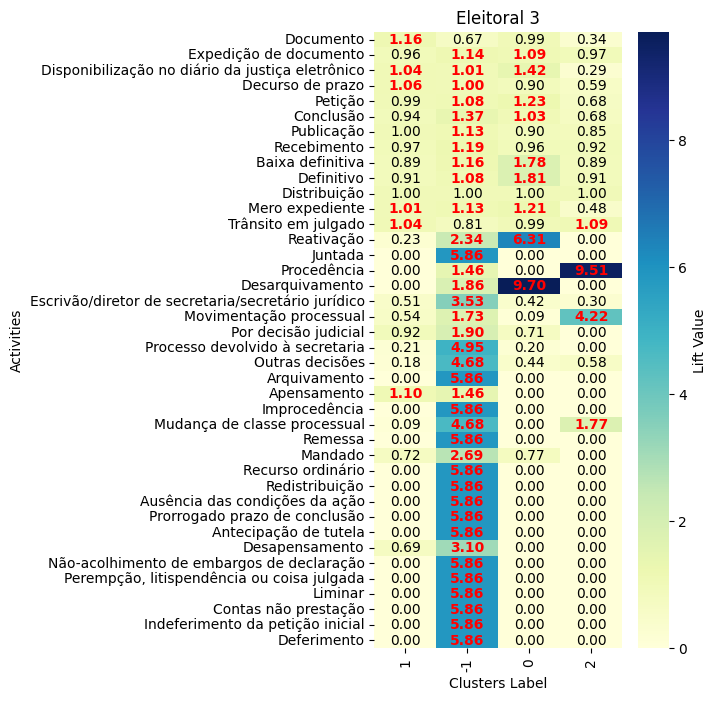

In [27]:
# Suponha que você tenha uma lista de clusters que deseja visualizar

# Filtrar o DataFrame para incluir apenas os clusters da lista
lift_por_cluster_filtrado = lift_por_cluster.loc[top_labels]

# Transpor o DataFrame para que os clusters sejam as linhas e as atividades as colunas
lift_por_cluster_transposto = lift_por_cluster_filtrado.transpose()

# Remover linhas onde todos os valores são zero
lift_por_cluster_transposto = lift_por_cluster_transposto.loc[~(lift_por_cluster_transposto == 0).all(axis=1)]

# Exibir o heatmap do Lift para os clusters selecionados
plt.figure(figsize=(4, 8))  # Ajuste o tamanho da figura conforme necessário

# Gerar o heatmap com configurações básicas para posteriormente ajustar as anotações
ax = sns.heatmap(lift_por_cluster_transposto, cmap="YlGnBu", annot=True, fmt=".2f",
                 cbar_kws={'label': 'Lift Value'})

# Após a criação do heatmap, ajustar a cor e o peso da fonte nas anotações
for i, j in np.ndindex(lift_por_cluster_transposto.shape):
    value = lift_por_cluster_transposto.iat[i, j]  # Usar iat para acesso rápido a elementos do DataFrame
    text = ax.texts[i * lift_por_cluster_transposto.shape[1] + j]
    text.set_color('red' if value > 1 else 'black')
    text.set_weight('bold' if value > 1 else 'normal')

# Adicionar título e rótulos
plt.title("Eleitoral 3")
plt.xlabel("Clusters Label")
plt.ylabel("Activities")

# Rotacionar as labels das atividades (eixo X) em 90 graus
plt.xticks(rotation=90)  # Rótulos de atividades no eixo X (vertical)
plt.yticks(rotation=0)   # Rótulos dos clusters no eixo Y (horizontal)

# Exibir a visualização
image_dir = f"{EXPERIMENT_PATH}/experiment_results"
os.makedirs(image_dir, exist_ok=True)
image_path = f"{image_dir}/T4U3_activities.png"

plt.savefig(image_path, bbox_inches='tight', dpi=300)
print(f'Imagem salva com sucesso no Drive em: {image_path}')
plt.show()


# Second table

In [28]:
def lift(cluster_cases, num_clusters, idx):
  return lift_TOS_TOM(cluster_cases, num_clusters, idx)

In [29]:
#(num_atv_cluster)/(total/n_clusters)
def lift_TOS_TOM(cluster_cases, num_clusters, idx):

  tos = cluster_cases.loc[idx, 'Number of times this activity appears in cluster']

  tom = cluster_cases.loc[idx, 'Total activity in court']/num_clusters

  return (round(tos/tom, 2))

In [30]:
def apply_thresh_frequency(activity_profile, frequency_thresh):

  activities = activity_profile['Activity'].unique()

  activities = sorted(activities, key=lambda x:x[3], reverse=True)

  activities = activities[:int(len(activities)*frequency_thresh)]

  return activity_profile[activity_profile['Activity'].isin(activities)]

In [31]:
#clusters with silhouette score > mean in court & all clusters
def simplified_list(court):
  simplified_list: list[dict[str, str | float]] = list()

  activities = court.drop(['cluster', 'silhouette'], axis=1).columns
  for activity in activities:
    #activity = activity.capitalize()

    for n_cluster in np.sort(court["cluster"].unique()):

      #activities per cluster
      activity_column = court.loc[court["cluster"]==n_cluster, activity]

      #total activity number per court
      total_activity_column = court.loc[:, activity].sum()

      #total number of cases per cluster
      total_cases_cluster = court.loc[court["cluster"]==n_cluster, "cluster"].count()

      #mean silhouette score in cluster
      silhouette_score_cluster = court[court['cluster'] == n_cluster]['silhouette'].mean()

      simplified_list.append({
          'cluster': int(n_cluster),
          'Activity': activity,
          'Number of times this activity appears in cluster': activity_column.sum(),
          'Total activity in court': total_activity_column,
          'Total number of cases in cluster': total_cases_cluster,
          'silhouette': silhouette_score_cluster,
      })

  return pd.DataFrame(simplified_list)

In [32]:
def create_table(simplified_courts, similarity_quality_thresh, max_clusters, activity_diff_num, frequency_thresh):
  for i in range(len(simplified_courts)):
    simplified_courts[i] = apply_thresh_frequency(simplified_courts[i], frequency_thresh)

  table_lift = {}

  table_courts = [{}, {}, {}]

  num_clusters = 20

  #Passo 1: Procurar clusters com mais processos (cases)
  #considerar apenas clusters com silhouette score > média

  for court in range(1):

      activity_profile = simplified_courts[court]

      table_court = table_courts[court]

      #Procurar os clusters que tiveram mais cases
      clusters = activity_profile.sort_values(by='Total number of cases in cluster', ascending=False)['cluster'].unique()

      cluster_sizes = {}
      for cluster in clusters:
        cluster_sizes[cluster] = activity_profile[activity_profile['cluster'] == cluster]['Total number of cases in cluster'].unique()[0]

      cluster_sizes = pd.Series(cluster_sizes, index=clusters)

      for cluster_id, count in cluster_sizes.items():

        #Encontrar clusters similares
        similar_clusters = cluster_sizes[(cluster_sizes >= count * (1 - similarity_quality_thresh)) &
                                        (cluster_sizes <= count * (1 + similarity_quality_thresh))]


        #se tiver uma quantidade similar de casos
        if len(similar_clusters) > 1:
          clusters_silhouette = {}

          for c, count in similar_clusters.items():

            if (f'Court {court+1}', f'{c}') in table_court.keys():
              similar_clusters = similar_clusters.drop(c)
              continue

            #calcula o silhouette score
            clusters_silhouette[c] = activity_profile[activity_profile['cluster'] == c]['silhouette'].mean()

          #Passo 2: selecionar o cluster com maior silhoutte score
          chosen_cluster = max(clusters_silhouette, key=clusters_silhouette.get)
          table_court[(f'Court {court+1}', f'{chosen_cluster}')] = []


        #se não tiver clusters similares
        else:
          table_court[(f'Court {court+1}', f'{cluster_id}')] = []

        #se atingir a quantidade max (desejada) de clusters por unidade
        if (len(table_court.items()) >= max_clusters) or (len(table_court.items()) >= cluster_sizes.size):
            table_court = sorted(table_court.items(), key=lambda x: x[0][1])
            table_lift.update(table_court)
            break

  #Passo 3: encontrar as atividades mais positivamente atrelado ao cluster (maior lift)

  #atividades selecionadas por unidade
  selected_activities = [[], [], []]

  selected_activities_qtd = []

  for (court, cluster), lifts in table_lift.items():
    court = int(court.split()[1])
    courtIdx = court - 1
    cluster = int(cluster)

    lifts_qdt = {}

    #Calcular lift
    cluster_cases = simplified_courts[courtIdx][simplified_courts[courtIdx]['cluster'] == cluster]

    #Calcular lift para cada atividade
    for idx in cluster_cases.index:
      activity = cluster_cases.loc[idx, 'Activity']

      if cluster_cases.loc[idx, 'Total activity in court'] > 0:
        lifts_qdt[activity] = lift(cluster_cases, num_clusters, idx)

    #selecionar atividades mais positivamente atreladas ao cluster
    top_activities_qtd = sorted(lifts_qdt.items(), key=lambda x: x[1], reverse=True)[:activity_diff_num]
    for activity in top_activities_qtd:

      if activity[0] not in selected_activities_qtd:
        selected_activities_qtd.append(activity[0])

      if activity[0] not in selected_activities[courtIdx]:
        selected_activities[courtIdx].append(activity[0])

  # Adicionar os lifts à tabela
  selected_activities_qtd.sort()
  for n in range(len(selected_activities)):
    selected_activities[n].sort()


  #recalcular os valores dos lifts para todas as atividades selecionadas
  for (court, cluster), lifts in table_lift.items():
    court = int(court.split()[1])
    courtIdx = court - 1
    cluster = int(cluster)

    table_lift[(f'Court {court}', f'{cluster}')] = []
    table_courts[courtIdx][(f'Court {court}', f'{cluster}')] = []

    cluster_cases = simplified_courts[courtIdx][simplified_courts[courtIdx]['cluster'] == cluster]

    for activity in selected_activities_qtd:
      qtd = cluster_cases[cluster_cases['Activity'] == activity]['Number of times this activity appears in cluster']
      if qtd.empty:
        qtd = 0
        table_lift[(f'Court {court}', f'{cluster}')].append(0.00)

        if activity in selected_activities[courtIdx]:
          table_courts[courtIdx][(f'Court {court}', f'{cluster}')].append(0.00)

      else:
        qtd = qtd.values[0]
        idx = cluster_cases[cluster_cases['Activity'] == activity].index.values[0]

        table_lift[(f'Court {court}', f'{cluster}')].append(lift(cluster_cases, num_clusters, idx))

        if activity in selected_activities[courtIdx]:
          table_courts[courtIdx][(f'Court {court}', f'{cluster}')].append(lift(cluster_cases, num_clusters, idx))


  #criar dataframes

  #todas as unidades
  table_lift['Activities'] = selected_activities_qtd
  table_qtd_df = pd.DataFrame(data=table_lift, index=table_lift['Activities'])
  table_qtd_df.set_index('Activities', inplace=True)

  #para cada unidade
  for n in range(len(selected_activities)):
    table_courts[n]['Activities'] = selected_activities[n]


  courts_df_1 = pd.DataFrame(data=table_courts[0], index=table_courts[0]['Activities'])
  courts_df_1.set_index('Activities', inplace=True)

  return courts_df_1

In [33]:
simplified_courts = [simplified_list(activity_profile_no_outliers)]

In [34]:
c1_p1 = create_table(simplified_courts.copy(), similarity_quality_thresh=0.1, max_clusters=10, activity_diff_num=20, frequency_thresh=1)

In [35]:
import pandas as pd

thresh_min = 2

# destacar os valores dentro do limiar
def highlight_with_threshold(s, thresh_min):
    max_value = s.max()
    return [
        'background-color: darkblue' if value >= thresh_min else ''
        for value in s
    ]

# função para plotar tabela
def plot_table(table_qtd_df, thresh_min=thresh_min):
  # Renomear as colunas
  table_qtd_df.columns = pd.MultiIndex.from_tuples(table_qtd_df.columns)
  table_qtd_df = table_qtd_df.reindex(
      columns=sorted(table_qtd_df.columns, key=lambda x: (x[0], x[1]))
  )

  table_ploted = (
      table_qtd_df.style
      .apply(highlight_with_threshold, thresh_min=thresh_min, axis=1)
      .format(precision=2)
      .set_properties(**{'text-align': 'center'})
  )
  return table_ploted

In [36]:
plot_table(c1_p1)